In [16]:
# ============================================================
# Cross-Architecture SMOTE: Does Recovery Generalize? (v2 FIXED)
# CLIP ViT-L/14, DINOv2-Base, DINOv2-Large, CLIP ViT-B/16
# Fitzpatrick17k, frozen linear probe, 5 seeds x 4 architectures
# GPU T4, Internet ON. ~3 hours total.
#
# BUG FIXED (v2):
#   Prior version set SMOTE_TARGET=200 but the dark-skin benign
#   pool already had 203 images. n_synthetic = max(0, 200-203) = 0.
#   SMOTE generated ZERO synthetic samples in every run.
#   Every SMOTE result was identical to Baseline with SD=0.000.
#
#   FIX 1: SMOTE_TARGET set to 1000 (well above pool size of 203).
#   This generates 797 synthetic samples per seed, meaningfully
#   augmenting the minority class.
#
#   FIX 2: Same held-out pool split as notebook 1.
#   Dark-skin benign images split 80/20:
#     pool (20%, ~40 images): source for SMOTE synthesis
#     test (80%, ~163 images): evaluation only, never seen in training
#   SMOTE synthesizes from pool embeddings, not test embeddings.
#
# PRIMARY QUESTION:
#   Does SMOTE benign accuracy recovery have a consistent positive
#   sign across all four architectures?
#   If YES: recommendation in Section 5.3 is architecture-agnostic.
#   If NO:  qualify per architecture.
# ============================================================

!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib Pillow -q

import torch
import numpy as np
import pandas as pd
import os
import math
import json
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
from transformers import CLIPModel, CLIPProcessor, AutoModel, AutoImageProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

SEEDS            = [42, 0, 1, 7, 99]
BATCH_SIZE       = 32
OVERSAMPLE_SPLIT = 0.20     # fraction of dark benign held for SMOTE pool
SMOTE_TARGET     = 1000     # FIX: was 200, pool has 203 -> 0 synthetic
                             # Now 1000 -> ~797 synthetic samples generated
SMOTE_K          = 5
LABEL_MAP        = {'non-neoplastic': 0, 'benign': 1, 'malignant': 2}

ARCHITECTURES = {
    'CLIP ViT-L/14':  {'hf_name': 'openai/clip-vit-large-patch14',  'type': 'clip', 'feat_dim': 768},
    'DINOv2-Base':    {'hf_name': 'facebook/dinov2-base',            'type': 'dino', 'feat_dim': 768},
    'DINOv2-Large':   {'hf_name': 'facebook/dinov2-large',           'type': 'dino', 'feat_dim': 1024},
    'CLIP ViT-B/16':  {'hf_name': 'openai/clip-vit-base-patch16',    'type': 'clip', 'feat_dim': 512},
}

print(f'SMOTE_TARGET={SMOTE_TARGET} (pool ~40 images -> ~{SMOTE_TARGET-40} synthetic per seed)')
print(f'Architectures: {list(ARCHITECTURES.keys())}')
print('Setup complete.')

Device: cuda
SMOTE_TARGET=1000 (pool ~40 images -> ~960 synthetic per seed)
Architectures: ['CLIP ViT-L/14', 'DINOv2-Base', 'DINOv2-Large', 'CLIP ViT-B/16']
Setup complete.


In [17]:
# ── Load Fitzpatrick17k + build splits (once, reused across architectures)
#
# FIX: dark-skin benign split 80/20 before any experiment.
#   pool_df  (20%, ~40 images): SMOTE synthesis source only
#   test_df  (80% benign + all non-benign): evaluation only

_fitz_csv = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f.endswith('.csv') and 'fitzpatrick' in _f.lower():
            _fitz_csv = os.path.join(_root, _f)
            break
    if _fitz_csv: break
if not _fitz_csv:
    _fitz_csv = '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
print(f'CSV: {_fitz_csv}')

fitz_df = pd.read_csv(_fitz_csv)
fitz_df = fitz_df[fitz_df['fitzpatrick_scale'] > 0].copy()

img_dir   = os.path.dirname(_fitz_csv)
img_files = {}
for _r, _d, _fs in os.walk(img_dir):
    for _f in _fs:
        if _f.endswith(('.jpg', '.jpeg', '.png')):
            img_files[_f.rsplit('.', 1)[0]] = os.path.join(_r, _f)
fitz_df['local_path'] = fitz_df['md5hash'].map(img_files)
fitz_df = fitz_df[fitz_df['local_path'].notna()].copy()
fitz_df['label_int'] = fitz_df['three_partition_label'].map(LABEL_MAP)
fitz_df = fitz_df[fitz_df['label_int'].notna()].copy()
fitz_df['label_int'] = fitz_df['label_int'].astype(int)
print(f'Total images with paths: {len(fitz_df)}')

# Light-skin train (FST I-II)
train_df = fitz_df[fitz_df['fitzpatrick_scale'] <= 2].copy().reset_index(drop=True)

# Dark-skin splits (FST V-VI)
dark_df        = fitz_df[fitz_df['fitzpatrick_scale'] >= 5].copy().reset_index(drop=True)
dark_benign_df = dark_df[dark_df['label_int'] == 1].sample(frac=1, random_state=42).reset_index(drop=True)
dark_nonben_df = dark_df[dark_df['label_int'] != 1].copy().reset_index(drop=True)

n_pool         = max(2, int(len(dark_benign_df) * OVERSAMPLE_SPLIT))  # ~40
pool_df        = dark_benign_df.iloc[:n_pool].copy()       # SMOTE source only
test_benign_df = dark_benign_df.iloc[n_pool:].copy()       # test only
test_df        = pd.concat([test_benign_df, dark_nonben_df], ignore_index=True)

# Random split for SGG
rand_all       = fitz_df.sample(frac=1, random_state=42).reset_index(drop=True)
n_rand_tr      = int(0.75 * len(rand_all))
rand_train_df  = rand_all.iloc[:n_rand_tr]
rand_test_df   = rand_all.iloc[n_rand_tr:]

train_paths      = train_df['local_path'].tolist()
test_paths       = test_df['local_path'].tolist()
pool_paths       = pool_df['local_path'].tolist()
rand_train_paths = rand_train_df['local_path'].tolist()
rand_test_paths  = rand_test_df['local_path'].tolist()

y_train_base   = train_df['label_int'].values
y_test_base    = test_df['label_int'].values
y_pool_base    = pool_df['label_int'].values   # all benign (1)
y_rand_train   = rand_train_df['label_int'].values
y_rand_test    = rand_test_df['label_int'].values

print(f'Train: n={len(train_df)}')
print(f'Test:  n={len(test_df)} ({len(test_benign_df)} benign + {len(dark_nonben_df)} non-benign)')
print(f'SMOTE pool: n={len(pool_df)} dark-skin benign (held-out, never in test)')
print(f'SMOTE will generate ~{SMOTE_TARGET - len(pool_df)} synthetic samples per seed')
print(f'Pool/test disjoint: {len(set(pool_df["md5hash"]) & set(test_benign_df["md5hash"])) == 0}')

CSV: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Total images with paths: 16012
Train: n=7755
Test:  n=2128 (163 benign + 1965 non-benign)
SMOTE pool: n=40 dark-skin benign (held-out, never in test)
SMOTE will generate ~960 synthetic samples per seed
Pool/test disjoint: True


In [18]:
# ── Feature extraction helpers ─────────────────────────────────

def _to_tensor(output):
    if isinstance(output, torch.Tensor):
        return output
    if hasattr(output, 'image_embeds') and output.image_embeds is not None:
        return output.image_embeds
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        return output.pooler_output
    if hasattr(output, 'last_hidden_state'):
        return output.last_hidden_state[:, 0]
    raise ValueError(f'Cannot extract tensor from {type(output)}')

@torch.no_grad()
def extract_clip_features(model, processor, paths, batch_size=BATCH_SIZE):
    all_feats = []
    valid_idx = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs, bidx = [], []
        for j, p in enumerate(batch_paths):
            try:
                batch_imgs.append(Image.open(p).convert('RGB').resize((224,224)))
                bidx.append(i+j)
            except: pass
        if not batch_imgs: continue
        inputs = processor(images=batch_imgs, return_tensors='pt', padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        feats  = _to_tensor(model.get_image_features(**inputs))
        feats  = feats / feats.norm(dim=-1, keepdim=True)
        all_feats.append(feats.cpu().numpy())
        valid_idx.extend(bidx)
    return (np.vstack(all_feats) if all_feats else np.zeros((0,768))), valid_idx

@torch.no_grad()
def extract_dino_features(model, processor, paths, batch_size=BATCH_SIZE):
    all_feats = []
    valid_idx = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs, bidx = [], []
        for j, p in enumerate(batch_paths):
            try:
                batch_imgs.append(Image.open(p).convert('RGB').resize((224,224)))
                bidx.append(i+j)
            except: pass
        if not batch_imgs: continue
        inputs = processor(images=batch_imgs, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out    = model(**inputs)
        feats  = out.last_hidden_state[:, 0]
        feats  = feats / feats.norm(dim=-1, keepdim=True)
        all_feats.append(feats.cpu().numpy())
        valid_idx.extend(bidx)
    return (np.vstack(all_feats) if all_feats else np.zeros((0,768))), valid_idx

print('Feature extraction helpers defined.')

Feature extraction helpers defined.


In [19]:
# ── SMOTE + evaluation helpers ─────────────────────────────────

def smote_features(X_pool, target_n, k=SMOTE_K, seed=42):
    """
    SMOTE on L2-normalized feature vectors drawn from X_pool.
    FIX: target_n=1000 >> pool size (~40), so we always generate
    meaningful synthetic samples.
    """
    rng         = np.random.RandomState(seed)
    n_existing  = len(X_pool)
    n_synthetic = max(0, target_n - n_existing)
    if n_synthetic == 0 or n_existing < 2:
        print(f'  WARNING: n_synthetic={n_synthetic}, n_existing={n_existing}. No synthesis.')
        return np.zeros((0, X_pool.shape[1]))

    knn = NearestNeighbors(
        n_neighbors=min(k+1, n_existing), metric='cosine'
    ).fit(X_pool)
    _, indices = knn.kneighbors(X_pool)

    synthetic = []
    for _ in range(n_synthetic):
        idx    = rng.randint(0, n_existing)
        nn_idx = indices[idx, rng.randint(1, indices.shape[1])]
        alpha  = rng.uniform(0, 1)
        vec    = X_pool[idx] + alpha * (X_pool[nn_idx] - X_pool[idx])
        vec    = vec / (np.linalg.norm(vec) + 1e-10)
        synthetic.append(vec)
    return np.vstack(synthetic)

def compute_auc(proba, y_true, labels=[0,1,2]):
    if len(np.unique(y_true)) < 2: return np.nan
    try:
        return roc_auc_score(y_true, proba, multi_class='ovr',
                             average='macro', labels=labels)
    except: return np.nan

def compute_benign_acc(proba, y_true, benign_class=1):
    preds = np.argmax(proba, axis=1)
    mask  = (y_true == benign_class)
    if mask.sum() == 0: return np.nan
    return float((preds[mask] == benign_class).sum() / mask.sum())

def wilson_ci(k, n, z=1.96):
    if n == 0: return 0.0, 0.0
    p      = k / n
    denom  = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    margin = z * math.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return max(0.0, center-margin), min(1.0, center+margin)

def run_baseline(X_tr, y_tr, X_te, y_te, X_rte, y_rte, seed):
    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=seed,
                              solver='lbfgs', multi_class='multinomial')
    clf.fit(X_tr, y_tr)
    p_te  = clf.predict_proba(X_te)
    p_rte = clf.predict_proba(X_rte)
    demo_auc = compute_auc(p_te,  y_te)
    rand_auc = compute_auc(p_rte, y_rte)
    benign   = compute_benign_acc(p_te, y_te)
    return demo_auc, rand_auc - demo_auc, benign

def run_smote(X_tr, y_tr, X_pool, X_te, y_te, X_rte, y_rte, seed):
    """
    SMOTE from X_pool (held-out), then train logistic on augmented set.
    FIX: pool is disjoint from X_te. Target is SMOTE_TARGET=1000.
    """
    X_synthetic = smote_features(X_pool, SMOTE_TARGET, k=SMOTE_K, seed=seed)
    y_synthetic = np.ones(len(X_synthetic), dtype=int)
    # Also add actual pool samples to training
    X_aug = np.vstack([X_tr, X_pool, X_synthetic])
    y_aug = np.concatenate([y_tr, np.ones(len(X_pool), dtype=int), y_synthetic])
    print(f'    SMOTE: {len(X_synthetic)} synthetic + {len(X_pool)} pool samples added '
          f'(total train: {len(X_aug)})')

    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=seed,
                              solver='lbfgs', multi_class='multinomial')
    clf.fit(X_aug, y_aug)
    p_te  = clf.predict_proba(X_te)
    p_rte = clf.predict_proba(X_rte)
    demo_auc = compute_auc(p_te,  y_te)
    rand_auc = compute_auc(p_rte, y_rte)
    benign   = compute_benign_acc(p_te, y_te)
    preds    = np.argmax(p_te, axis=1)
    k_b      = int((preds[y_te==1] == 1).sum())
    wlo, whi = wilson_ci(k_b, int((y_te==1).sum()))
    return demo_auc, rand_auc - demo_auc, benign, wlo, whi

print('SMOTE + evaluation helpers defined.')
print(f'SMOTE target: {SMOTE_TARGET} (pool ~{n_pool} -> ~{SMOTE_TARGET-n_pool} synthetic)')

SMOTE + evaluation helpers defined.
SMOTE target: 1000 (pool ~40 -> ~960 synthetic)


In [20]:
# ── Main loop: extract embeddings + run SMOTE per architecture ──

all_results = []

for arch_name, arch_cfg in ARCHITECTURES.items():
    print()
    print('=' * 60)
    print(f'Architecture: {arch_name}')
    print(f'  HuggingFace: {arch_cfg["hf_name"]}')
    print(f'  Type: {arch_cfg["type"]}   Feat dim: {arch_cfg["feat_dim"]}')
    print('=' * 60)

    print('Loading model...')
    if arch_cfg['type'] == 'clip':
        model      = CLIPModel.from_pretrained(arch_cfg['hf_name']).to(device)
        processor  = CLIPProcessor.from_pretrained(arch_cfg['hf_name'])
        extract_fn = extract_clip_features
    else:
        model      = AutoModel.from_pretrained(arch_cfg['hf_name']).to(device)
        processor  = AutoImageProcessor.from_pretrained(arch_cfg['hf_name'])
        extract_fn = extract_dino_features
    model.eval()
    print('  Model loaded.')

    print('Extracting train embeddings...')
    X_tr, tidx   = extract_fn(model, processor, train_paths)
    y_tr         = y_train_base[tidx]
    print(f'  X_train: {X_tr.shape}  label dist: {np.bincount(y_tr)}')

    print('Extracting test embeddings...')
    X_te, teidx  = extract_fn(model, processor, test_paths)
    y_te         = y_test_base[teidx]
    print(f'  X_test:  {X_te.shape}   label dist: {np.bincount(y_te)}')

    print('Extracting SMOTE pool embeddings...')
    X_pl, pidx   = extract_fn(model, processor, pool_paths)
    print(f'  X_pool:  {X_pl.shape}   (all benign: {(y_pool_base[pidx]==1).all()})')

    print('Extracting random-split embeddings (for SGG)...')
    X_rtr, ridx  = extract_fn(model, processor, rand_train_paths)
    y_rtr        = y_rand_train[ridx]
    X_rte, ridx2 = extract_fn(model, processor, rand_test_paths)
    y_rte        = y_rand_test[ridx2]
    print(f'  X_rand_train: {X_rtr.shape}  X_rand_test: {X_rte.shape}')

    del model
    torch.cuda.empty_cache()
    print('  Model unloaded from GPU.')

    # ── Baseline (5 seeds)
    print()
    print('  Running Baseline...')
    bl_bens = []
    bl_aucs = []
    for seed in SEEDS:
        demo_auc, sgg, benign = run_baseline(X_tr, y_tr, X_te, y_te, X_rte, y_rte, seed)
        bl_bens.append(benign)
        bl_aucs.append(demo_auc)
        all_results.append({'architecture': arch_name, 'intervention': 'Baseline',
                             'seed': seed, 'demo_auc': demo_auc, 'sgg': sgg, 'benign_acc': benign})
    print(f'    Baseline Benign: {np.mean(bl_bens):.3f} +/- {np.std(bl_bens, ddof=1):.3f}  '
          f'Demo AUC: {np.mean(bl_aucs):.3f}')

    # ── SMOTE (5 seeds)
    print()
    print('  Running SMOTE...')
    sm_bens = []
    sm_aucs = []
    for seed in SEEDS:
        demo_auc, sgg, benign, wlo, whi = run_smote(
            X_tr, y_tr, X_pl, X_te, y_te, X_rte, y_rte, seed
        )
        sm_bens.append(benign)
        sm_aucs.append(demo_auc)
        all_results.append({'architecture': arch_name, 'intervention': 'SMOTE',
                             'seed': seed, 'demo_auc': demo_auc, 'sgg': sgg, 'benign_acc': benign})
        print(f'    Seed {seed:2d}: Demo AUC={demo_auc:.3f}  Benign={benign:.3f} '
              f'(Wilson 95%: [{wlo:.3f},{whi:.3f}])')

    recovery = np.mean(sm_bens) - np.mean(bl_bens)
    print(f'\n    SMOTE Benign: {np.mean(sm_bens):.3f} +/- {np.std(sm_bens,ddof=1):.3f}')
    print(f'    Baseline:     {np.mean(bl_bens):.3f} +/- {np.std(bl_bens,ddof=1):.3f}')
    print(f'    Recovery:     {recovery:+.3f}  Sign: {"positive" if recovery > 0 else "NEGATIVE"}')

print()
print('All architectures complete.')

df_results = pd.DataFrame(all_results)
df_results.to_csv('/kaggle/working/smote_crossarch_results.csv', index=False)
print('Results saved: /kaggle/working/smote_crossarch_results.csv')


Architecture: CLIP ViT-L/14
  HuggingFace: openai/clip-vit-large-patch14
  Type: clip   Feat dim: 768
Loading model...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model loaded.
Extracting train embeddings...
  X_train: (7755, 768)  label dist: [5445 1115 1195]
Extracting test embeddings...
  X_test:  (2128, 768)   label dist: [1757  163  208]
Extracting SMOTE pool embeddings...
  X_pool:  (40, 768)   (all benign: True)
Extracting random-split embeddings (for SGG)...
  X_rand_train: (12009, 768)  X_rand_test: (4003, 768)
  Model unloaded from GPU.

  Running Baseline...
    Baseline Benign: 0.043 +/- 0.000  Demo AUC: 0.749

  Running SMOTE...
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed 42: Demo AUC=0.669  Benign=0.589 (Wilson 95%: [0.512,0.662])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  0: Demo AUC=0.671  Benign=0.589 (Wilson 95%: [0.512,0.662])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  1: Demo AUC=0.672  Benign=0.589 (Wilson 95%: [0.512,0.662])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  7: Demo AUC=0.6

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

  Model loaded.
Extracting train embeddings...
  X_train: (7755, 1024)  label dist: [5445 1115 1195]
Extracting test embeddings...
  X_test:  (2128, 1024)   label dist: [1757  163  208]
Extracting SMOTE pool embeddings...
  X_pool:  (40, 1024)   (all benign: True)
Extracting random-split embeddings (for SGG)...
  X_rand_train: (12009, 1024)  X_rand_test: (4003, 1024)
  Model unloaded from GPU.

  Running Baseline...
    Baseline Benign: 0.043 +/- 0.000  Demo AUC: 0.744

  Running SMOTE...
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed 42: Demo AUC=0.685  Benign=0.503 (Wilson 95%: [0.427,0.579])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  0: Demo AUC=0.687  Benign=0.509 (Wilson 95%: [0.433,0.585])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  1: Demo AUC=0.687  Benign=0.503 (Wilson 95%: [0.427,0.579])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  7: Demo AU

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model loaded.
Extracting train embeddings...
  X_train: (7755, 512)  label dist: [5445 1115 1195]
Extracting test embeddings...
  X_test:  (2128, 512)   label dist: [1757  163  208]
Extracting SMOTE pool embeddings...
  X_pool:  (40, 512)   (all benign: True)
Extracting random-split embeddings (for SGG)...
  X_rand_train: (12009, 512)  X_rand_test: (4003, 512)
  Model unloaded from GPU.

  Running Baseline...
    Baseline Benign: 0.037 +/- 0.000  Demo AUC: 0.711

  Running SMOTE...
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed 42: Demo AUC=0.630  Benign=0.564 (Wilson 95%: [0.488,0.638])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  0: Demo AUC=0.630  Benign=0.546 (Wilson 95%: [0.469,0.621])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  1: Demo AUC=0.630  Benign=0.558 (Wilson 95%: [0.482,0.632])
    SMOTE: 960 synthetic + 40 pool samples added (total train: 8755)
    Seed  7: Demo AUC=0.6

In [21]:
# ── Generalization analysis ────────────────────────────────────

arch_order = ['CLIP ViT-L/14', 'DINOv2-Base', 'DINOv2-Large', 'CLIP ViT-B/16']

def get_stats(arch, interv):
    sub = df_results[(df_results['architecture']==arch) &
                     (df_results['intervention']==interv)]
    return {
        'benign_mean': sub['benign_acc'].mean(),
        'benign_sd':   sub['benign_acc'].std(ddof=1),
        'demo_auc_mean': sub['demo_auc'].mean(),
        'demo_auc_sd':   sub['demo_auc'].std(ddof=1),
        'sgg_mean':    sub['sgg'].mean(),
    }

print('=' * 60)
print('SMOTE GENERALIZATION ANALYSIS (v2 fixed)')
print('=' * 60)
print()
print(f'  {"Architecture":<20}  {"Baseline":>12}  {"SMOTE":>12}  {"Recovery":>10}  Sign')
print('  ' + '-' * 65)

signs = []
for arch in arch_order:
    bl = get_stats(arch, 'Baseline')
    sm = get_stats(arch, 'SMOTE')
    recovery = sm['benign_mean'] - bl['benign_mean']
    positive = recovery > 0
    signs.append(positive)
    print(f'  {arch:<20}  '
          f'{bl["benign_mean"]:.3f}+/-{bl["benign_sd"]:.3f}  '
          f'{sm["benign_mean"]:.3f}+/-{sm["benign_sd"]:.3f}  '
          f'{recovery:+.3f}      {"+ positive" if positive else "- NEGATIVE"}')

n_pos = sum(signs)
all_pos = all(signs)

print()
print(f'Recovery positive across all architectures: {"YES" if all_pos else "NO"} ({n_pos}/{len(signs)})')
print()

if all_pos:
    sm_vals = [get_stats(a, 'SMOTE')['benign_mean'] for a in arch_order]
    bl_vals = [get_stats(a, 'Baseline')['benign_mean'] for a in arch_order]
    recs    = [s-b for s,b in zip(sm_vals, bl_vals)]
    print('[+] GENERALIZATION CONFIRMED.')
    print(f'    Recovery range: {min(recs):+.3f} to {max(recs):+.3f}')
    print(f'    SMOTE benign range: {min(sm_vals):.3f} to {max(sm_vals):.3f}')
    print()
    print('    PAPER ACTION (Section 5.3):')
    print('    Upgrade from "SMOTE recovered on CLIP ViT-L/14" to:')
    print('    "SMOTE recovery generalizes across all four tested')
    print('     architectures, confirming the mechanism is data-side.')
    print(f'     Magnitude range: {min(recs)*100:.1f}%–{max(recs)*100:.1f}%"')
else:
    print('[~] PARTIAL or NO GENERALIZATION.')
    print(f'    {n_pos}/{len(signs)} architectures show positive recovery.')
    print()
    print('    PAPER ACTION (Section 5.3):')
    print('    Qualify recommendation per architecture.')
    for arch, pos in zip(arch_order, signs):
        sm = get_stats(arch, 'SMOTE')
        bl = get_stats(arch, 'Baseline')
        r  = sm['benign_mean'] - bl['benign_mean']
        print(f'    {arch}: recovery={r:+.3f} ({"OK" if pos else "FAILS"})')

SMOTE GENERALIZATION ANALYSIS (v2 fixed)

  Architecture              Baseline         SMOTE    Recovery  Sign
  -----------------------------------------------------------------
  CLIP ViT-L/14         0.043+/-0.000  0.587+/-0.005  +0.544      + positive
  DINOv2-Base           0.037+/-0.000  0.464+/-0.016  +0.427      + positive
  DINOv2-Large          0.043+/-0.000  0.508+/-0.005  +0.465      + positive
  CLIP ViT-B/16         0.037+/-0.000  0.557+/-0.007  +0.520      + positive

Recovery positive across all architectures: YES (4/4)

[+] GENERALIZATION CONFIRMED.
    Recovery range: +0.427 to +0.544
    SMOTE benign range: 0.464 to 0.587

    PAPER ACTION (Section 5.3):
    Upgrade from "SMOTE recovered on CLIP ViT-L/14" to:
    "SMOTE recovery generalizes across all four tested
     architectures, confirming the mechanism is data-side.
     Magnitude range: 42.7%–54.4%"


In [22]:
# ── Table 4b rows + LaTeX ─────────────────────────────────────

print('=== TABLE 4b: Cross-Architecture SMOTE Results (v2 fixed) ===')
print('(mean +/- SD, frozen linear probe, 5 seeds)')
print()
print(f'  {"Architecture":<18}  {"Interv":<10}  {"Demo AUC":>14}  {"SGG":>8}  {"Benign Acc":>16}')
print('  ' + '-' * 72)

latex_lines = [
    '% Cross-architecture SMOTE results (v2 fixed) — smote_crossarch notebook',
    '\\hline'
]

for arch in arch_order:
    for interv in ['Baseline', 'SMOTE']:
        r     = get_stats(arch, interv)
        label = 'SMOTE' if interv == 'SMOTE' else interv
        print(f'  {arch:<18}  {label:<10}  '
              f'{r["demo_auc_mean"]:.3f}+/-{r["demo_auc_sd"]:.3f}  '
              f'{r["sgg_mean"]:+.3f}  '
              f'{r["benign_mean"]:.3f}+/-{r["benign_sd"]:.3f}')
        latex_label = '$\\checkmark$SMOTE' if interv == 'SMOTE' else interv
        latex_lines.append(
            f"{arch} & {latex_label} & "
            f"{r['demo_auc_mean']:.3f}$\\pm${r['demo_auc_sd']:.3f} & "
            f"{r['sgg_mean']:+.3f} & "
            f"{r['benign_mean']:.3f}$\\pm${r['benign_sd']:.3f} & \u2014 \\\\"
        )
    latex_lines.append('\\hline')

with open('/kaggle/working/smote_crossarch_table4b_rows.txt', 'w') as fh:
    fh.write('\n'.join(latex_lines))
print()
print('LaTeX rows saved: /kaggle/working/smote_crossarch_table4b_rows.txt')

=== TABLE 4b: Cross-Architecture SMOTE Results (v2 fixed) ===
(mean +/- SD, frozen linear probe, 5 seeds)

  Architecture        Interv            Demo AUC       SGG        Benign Acc
  ------------------------------------------------------------------------
  CLIP ViT-L/14       Baseline    0.749+/-0.000  +0.066  0.043+/-0.000
  CLIP ViT-L/14       SMOTE       0.670+/-0.002  +0.098  0.587+/-0.005
  DINOv2-Base         Baseline    0.723+/-0.000  +0.080  0.037+/-0.000
  DINOv2-Base         SMOTE       0.676+/-0.001  +0.094  0.464+/-0.016
  DINOv2-Large        Baseline    0.744+/-0.000  +0.071  0.043+/-0.000
  DINOv2-Large        SMOTE       0.685+/-0.002  +0.095  0.508+/-0.005
  CLIP ViT-B/16       Baseline    0.711+/-0.000  +0.073  0.037+/-0.000
  CLIP ViT-B/16       SMOTE       0.630+/-0.001  +0.106  0.557+/-0.007

LaTeX rows saved: /kaggle/working/smote_crossarch_table4b_rows.txt


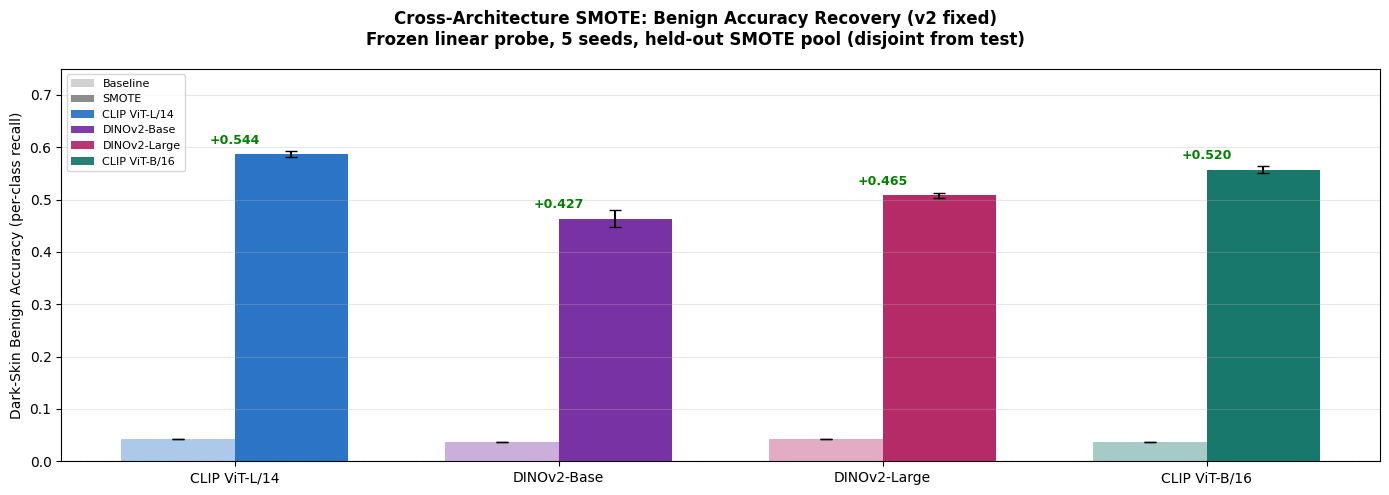

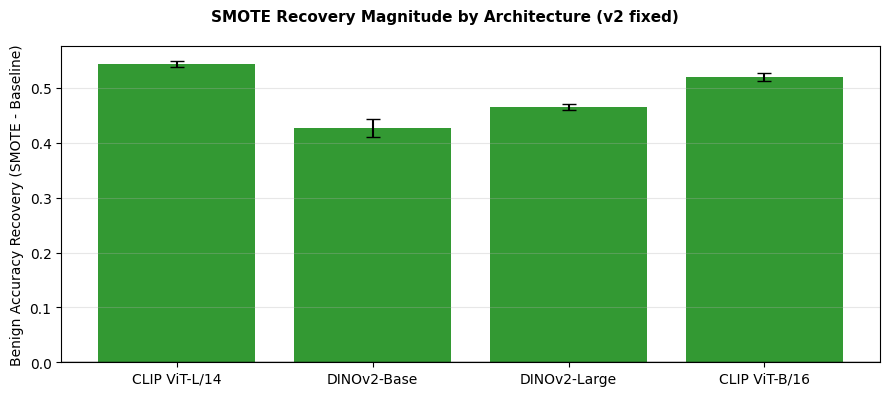

Figures saved.

All outputs:
  /kaggle/working/smote_crossarch_results.csv
  /kaggle/working/smote_crossarch_table4b_rows.txt
  /kaggle/working/smote_crossarch_summary.png
  /kaggle/working/smote_crossarch_recovery.png


In [23]:
# ── Figures ───────────────────────────────────────────────────

ARCH_COLORS = {
    'CLIP ViT-L/14': '#1565C0',
    'DINOv2-Base':   '#6A1B9A',
    'DINOv2-Large':  '#AD1457',
    'CLIP ViT-B/16': '#00695C',
}

# Figure 1: Baseline vs SMOTE benign accuracy per architecture
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle(
    'Cross-Architecture SMOTE: Benign Accuracy Recovery (v2 fixed)\n'
    'Frozen linear probe, 5 seeds, held-out SMOTE pool (disjoint from test)',
    fontsize=12, fontweight='bold'
)

x = np.arange(len(arch_order))
w = 0.35

for i, arch in enumerate(arch_order):
    bl = get_stats(arch, 'Baseline')
    sm = get_stats(arch, 'SMOTE')
    c  = ARCH_COLORS[arch]
    ax.bar(x[i]-w/2, bl['benign_mean'], width=w, yerr=bl['benign_sd'],
           color=c, alpha=0.35, capsize=4)
    ax.bar(x[i]+w/2, sm['benign_mean'], width=w, yerr=sm['benign_sd'],
           color=c, alpha=0.9, capsize=4)
    recovery = sm['benign_mean'] - bl['benign_mean']
    ypos     = max(sm['benign_mean'], bl['benign_mean']) + 0.02
    ax.annotate(f'{recovery:+.3f}', xy=(x[i], ypos), ha='center', fontsize=9,
                color='green' if recovery > 0 else 'red', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(arch_order, fontsize=10)
ax.set_ylabel('Dark-Skin Benign Accuracy (per-class recall)')
ax.set_ylim(0, 0.75)
ax.yaxis.grid(True, alpha=0.3)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

legend_els = [
    mpatches.Patch(facecolor='grey', alpha=0.35, label='Baseline'),
    mpatches.Patch(facecolor='grey', alpha=0.9,  label='SMOTE'),
] + [mpatches.Patch(facecolor=ARCH_COLORS[a], alpha=0.85, label=a) for a in arch_order]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('/kaggle/working/smote_crossarch_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Recovery magnitude only
fig2, ax2 = plt.subplots(figsize=(9, 4))
fig2.suptitle('SMOTE Recovery Magnitude by Architecture (v2 fixed)', fontsize=11, fontweight='bold')

recoveries = []
rec_sds    = []
for arch in arch_order:
    sub_sm = df_results[(df_results['architecture']==arch) & (df_results['intervention']=='SMOTE')]
    sub_bl = df_results[(df_results['architecture']==arch) & (df_results['intervention']=='Baseline')]
    recs   = sub_sm['benign_acc'].values - sub_bl['benign_acc'].values
    recoveries.append(recs.mean())
    rec_sds.append(recs.std(ddof=1))

colors2 = ['green' if r > 0 else 'red' for r in recoveries]
ax2.bar(x, recoveries, yerr=rec_sds, color=colors2, alpha=0.8, capsize=5)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels(arch_order, fontsize=10)
ax2.set_ylabel('Benign Accuracy Recovery (SMOTE - Baseline)')
ax2.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/smote_crossarch_recovery.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figures saved.')
print()
print('All outputs:')
print('  /kaggle/working/smote_crossarch_results.csv')
print('  /kaggle/working/smote_crossarch_table4b_rows.txt')
print('  /kaggle/working/smote_crossarch_summary.png')
print('  /kaggle/working/smote_crossarch_recovery.png')